In [ ]:
from IPython.display import display, Math, Latex

import pandas as pd
import numpy as np
import numpy_financial as npf
import yfinance as yf
import matplotlib.pyplot as plt
import random
from datetime import datetime

### Contributor Names: Muhammad Ali, Joey, Saren
### ________________________________________________________________________________________________
## General Strategy Overview
### 1. Stock Selection and Filtering
For each surviving stock, we then pull market data and compute a broad set of metrics: mean daily returns, volatility, Sharpe ratio, beta, residual alpha/momentum, beta stability, liquidity measures (average volume and volatility of volume), market cap converted to CAD, and sector/size buckets. We apply hard filters to remove low-quality or unreliable names (e.g., extreme or nonsensical Sharpe ratios, unstable betas, illiquid microcaps), leaving a clean investable universe.
### 2. Ranking Through Total Scoring
On this filtered set of tickers, every stock receives a single total score that blends four components:
- Our Initial Score (residual momentum, Sharpe, beta stability, etc.), which captures our core multi-factor signal.
- Monte Carlo–based score that simulate forward-looking return behaviour.
- CAPM expected return score, taken from each stock’s beta and the blended market’s expected return.
- Covariance/diversification score, favouring stocks that improve overall portfolio diversification.

Each component is normalized (since they have different scales we need to make sure they're actually comparable), then weighted (Initial Score as the largest weight, then Monte Carlo, CAPM, and covariance) to form the final Total Score. We then sort all stocks by Total Score (highest to lowest) and build a core portfolio of 10 names by walking down the list and adding stocks subject to a maximum of 4 names per sector. This step ensures we are selecting our highest-belief ideas while already imposing a basic sector diversification rule.
### 3. Portfolio Weighting
For the selected stocks, we convert the Total Score into weights for the portfolio by setting each stock’s weight proportional to its Total Score (Stock's Total Score / Sum of all Total Score in top 10) and normalizing so the 10 weights sum to 100%. High-score names automatically get larger allocations.
- Per-stock cap (15%)
- Any stock with a weight above 15% is capped at 15%. The excess weight that gets chopped off is redistributed across the remaining under-cap stocks in proportion to their Total Score. This step is repeated until no stock exceeds 15% and the total still sums to 100%, so we remain fully invested while respecting the single-stock limit.
- Per-sector cap (40%) and extension beyond 10 stocks

Next, we compute sector weights. If all sectors are ≤40%, we are done. If a sector exceeds 40% (for example, four tech names totalling 60%), we:
- Trim that sector down to exactly 40% by reducing weights of the lower-scoring stocks in that sector first, keeping the highest-scoring ones as close to 15% as possible.
- Track the freed-up weight (e.g., 20% in this example), and use it to add additional stocks from the global Total Score ranking: names #11, #12, #13, etc.
- Each new stock is added only if its sector remains ≤40% after inclusion, and its weight is kept below the smallest weight among the original top-10 holdings, so the new names enhance diversification without overshadowing the main ideas.
- 
After all caps and adjustments, we renormalize so the final weights sum to (approximately) 100% of the portfolio. We then convert these weights into CAD notional amounts using the \\$1,000,000 budget, apply FX adjustments for USD-denominated tickers, choose the cheaper of the two transaction cost options for each trade, and compute (possibly fractional) share amounts such that total cost including fees does not exceed $1,000,000.
### 4. Final Portfolio and Evaluation
- 10–25 stocks,
- no stock above 15%,
- no sector above 40%,
- all positions long-only and in CAD after the FX conversion.

We output a clean summary table showing each ticker, sector, key scores, final weight, and CAD invested amount, along with aggregate portfolio stats such as total invested capital (including fees) and any remaining cash. Because the Total Score itself blends residual momentum, Sharpe, CAPM, covariance, and Monte Carlo information, the final portfolio is explicitly designed to balance expected return, risk, and diversification under realistic constraints, rather than simply mirroring the market.


In [14]:
# 1) Clean ticker dataframe (no whitespace, no garbage, no duplicates, etc.)
def clean_ticker_dataframe(df, colname=None):

    if colname is None:
        # assume first column is the ticker column
        colname = df.columns[0]

    df = df.copy()

    # Force to string + strip spaces
    df[colname] = (
        df[colname]
        .astype(str)
        .str.strip()
    )

    # Empty strings → NaN
    df[colname] = df[colname].replace("", np.nan)

    # Drop missing tickers
    df = df.dropna(subset=[colname])

    # Uppercase everything (AAPL, MSFT, etc.)
    df[colname] = df[colname].str.upper()

    # Only allow letters, digits, dot, dash.
    # Also skip rows starting with "#" or containing spaces.
    mask_valid = (
        ~df[colname].str.startswith("#")
        & ~df[colname].str.contains(r"\s", regex=True)
        & df[colname].str.match(r"^[A-Z0-9\.\-]+$")
    )
    df = df[mask_valid]

    # Remove duplicates
    df = df.drop_duplicates(subset=[colname])

    # Clean reset
    return df.reset_index(drop=True)



# 2) Early CSV sanity check (must have >=10 stocks AND sector diversity)
def check_min_stocks_and_sector_diversity(df,
                                          min_stocks=10,
                                          min_sectors=3):
    """
    This is the early hard-stop gatekeeper.
    It checks two things right after cleaning:
      1. We have at least min_stocks tickers.
      2. Using yfinance, check that we have at least min_sectors real sectors.
         (This ensures we can actually obey the 40% sector cap rule.)

    If either fails, we print a clear message and exit immediately.
    """

    # We only need the ticker column here
    if "ticker" not in df.columns:
        raise SystemExit("CSV Error: The file is missing a 'ticker' column.")

    tickers = df["ticker"].dropna().unique()
    n = len(tickers)

    # -------- Check #1: enough stocks --------
    if n < min_stocks:
        print(f"Critical Error: Only {n} tickers found after cleaning.")
        print(f"At least {min_stocks} valid, non-duplicate tickers are required.")
        print("Fix the CSV and re-run.")
        raise SystemExit("Execution stopped: insufficient tickers in CSV.")

    # -------- Check #2: enough sectors --------
    sectors = []
    for t in tickers:
        try:
            info = yf.Ticker(t).info
            sector = info.get("sector", "Unknown")
        except Exception:
            sector = "Unknown"
        sectors.append(sector)

    # Count sectors excluding "Unknown"
    unique_real_sectors = {s for s in sectors if s != "Unknown"}
    num_sectors = len(unique_real_sectors)

    if num_sectors < min_sectors:
        print(f"Critical Error: Only {num_sectors} real sector(s) detected.")
        print("Your CSV tickers are not diversified enough to satisfy the")
        print("40% per-sector rule. Add more sectors and try again.")
        raise SystemExit("Execution stopped: insufficient sector diversity.")

    # If everything is good, return the clean df
    return df


<span style="color: red;">The function above were added post-submission to protect against any tomfoolery</span>

## Step 1: Stock Selection

Our stock selection was decided on by a set of metrics that each capture a different dimension of how a certain stock behaves. Mean daily return (μ) tells us whether the stock generally trends upwards over time while volatility (σ) shows how much a stock's price jumps around and how risky it is to hold. The Sharpe ratio combines these two into a single measure of how much return the stock provides per unit of risk, which obviously helps us to avoid stocks that are extremely risky, but don't actually provide a proportional gain.

Beta measures how sensitive a stock is to the overall market, and residual alpha tells us whether the stock has historically earned more (or less) than its Beta predicts based on CAPM, giving us a sense of whether it has genuine return potential beyond what the market explains. Beta stability ensures that this relationship with the market is consistent over time rather than unpredictable. Then, we have to make sure our stocks have enough volume to actually trade, so we consider average daily volume and "vol-of-vol", which shows how liquid the stock is and how stable that liquidity is from day to day. Residual momentum looks at whether the stock has recently outperformed its CAPM prediction in the last month, which demonstrates a stock's strength short-term while considering market risk.

Before we even start ranking, we also sanity-check the input file itself. We clean the TA’s CSV for any formatting tricks (leading/trailing spaces, blank rows, junk text, duplicates), then apply our hard filters. If, after this cleaning and filtering, there are fewer than 10 valid tickers or if all valid tickers come from a single sector, we stop the program and return a message. That’s because our strategy requires a 10–25 stock portfolio with a 40% sector cap, and mathematically you just can’t build that from too few names or from a one-sector universe.

### Cross-Listed Stocks

One thing we decided **not** to do at the cleaning stage is collapse cross-listed stocks into a single “company.” For example, if the CSV includes both SHOP and SHOP.TO, we deliberately treat them as two separate tickers instead of forcing ourselves to pick only one. There are a few reasons for this.

Our risk controls already stop cross-listed names from blowing up the portfolio. We still enforce a hard 15% cap per ticker, a 40% cap per sector, and we include covariance in the Total Score so that two almost-identical return series don’t both get huge weight. In other words, even if both SHOP and SHOP.TO score well, the combination of per-stock caps, sector caps, and the diversification penalty keeps us from accidentally turning the whole portfolio into Shopify 2.0.

Finally, we think this is more honest to how markets actually work. Cross listings are part of real-world markets, and part of building a robust strategy is handling them with proper constraints instead of pretending they don’t exist. So we allow cross-listed stocks to survive the filters, but we rely on our scoring system and portfolio construction rules to keep any one economic company from dominating the portfolio.

In [15]:
# 1. Function to calculate total return for a ticker over a time period
# I use this to measure how much something moved from start to end.
# .dropna() removes missing values because sometimes a stock has days with no data.
def get_total_return(ticker, time):
    shares = yf.Ticker(ticker).history(period=time)['Close'].dropna()

    if len(shares) < 2:
        raise ValueError("Not enough data returned for " + ticker)

    start = shares.iloc[0]
    end = shares.iloc[-1]

    return (end - start) / start

# 2. Load all tickers from the TA-provided file
# Change file name to whatever csv file you choose
# The CSV only has one column so I rename it to “ticker”.
alltickers_df = pd.read_csv("popular_stocks_single_column_2025-12-04.csv", dtype=str)
alltickers_df = clean_ticker_dataframe(alltickers_df, colname=alltickers_df.columns[0])
alltickers_df.columns = ["ticker"]

alltickers_df = check_min_stocks_and_sector_diversity(alltickers_df)

alltickers = alltickers_df["ticker"].tolist()



# 3. Detect country using yfinance “currency” tag.
# This tells me if the stock is CAD or USD. Anything else I ignore.
def detect_country(t):
    info = yf.Ticker(t).info
    currency = info.get("currency")

    if currency == "CAD":
        return "CA"
    elif currency == "USD":
        return "US"
    else:
        return "other"

# 4. Apply the country check to every ticker
tickers_country = pd.DataFrame({
    "ticker": alltickers,
    "country": [detect_country(t) for t in alltickers]})

# I only keep CA and US tickers. Everything else is removed.
valid_df = tickers_country[tickers_country["country"].isin(["CA", "US"])].copy()
valid_df = valid_df[["ticker"]].reset_index(drop=True)

# 5. Download historical data for all valid tickers (more efficient to do in one call)
start_date_required = '2024-10-01'
end_date_required = '2025-09-30'

all_tickers = valid_df["ticker"].tolist()

data = yf.download(
    tickers=all_tickers,
    start=start_date_required,
    end=end_date_required,
    group_by='ticker',
    threads=True)

# 6. Apply volume rule
# I remove tickers that don’t trade at least 18 days / month and don’t average 5000+ volume.
volume_list = []

for t in all_tickers:
    try:
        # I drop rows where Volume is missing so I don’t break the calculations.
        df = data[t].dropna(subset=["Volume"]).copy()
    except KeyError:
        volume_list.append([t, None])
        continue

    if df.empty:
        volume_list.append([t, None])
        continue

    df.index = pd.to_datetime(df.index).tz_localize(None)
    df["YearMonth"] = df.index.to_period("M")

    # Count how many days this stock traded each month
    days_per_month = df.groupby("YearMonth").size()

    # Only months with at least 18 trading days count
    valid_months = days_per_month[days_per_month >= 18].index

    filtered = df[df["YearMonth"].isin(valid_months)]

    if filtered.empty:
        volume_list.append([t, None])
        continue

    avg_vol = filtered["Volume"].mean()
    volume_list.append([t, avg_vol])

# 7. Build a dataframe of tickers and their average volumes
volume_df = pd.DataFrame(volume_list, columns=["ticker", "avg_volume"])

# 8. Filter tickers that pass the 5000 volume rule
final_step1_df = volume_df.dropna()
final_step1_df = final_step1_df[final_step1_df["avg_volume"] >= 5000].reset_index(drop=True)


Critical Error: Only 0 tickers found after cleaning.
At least 10 valid, non-duplicate tickers are required.
Fix the CSV and re-run.


SystemExit: Execution stopped: insufficient tickers in CSV.

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# 1. Set how far back I want to look for daily returns
time = "1y"

# Convert annual risk-free rate into a daily number (just divide by 365)
Rf = 0.0325 / 365

# 2. I pull the daily % changes for S&P500 and TSX.
# These give me a blended “market return” that I will use for beta calculations.
sp = yf.Ticker("^GSPC").history(period=time)["Close"].pct_change().dropna()
tsx = yf.Ticker("^GSPTSE").history(period=time)["Close"].pct_change().dropna()

# I combine them into one dataframe and take the average.
market_df = pd.concat([sp, tsx], axis=1).dropna()
market_df.columns = ["sp", "tsx"]
market_returns = 0.5 * market_df["sp"] + 0.5 * market_df["tsx"]

# 3. Helper to pull daily % changes for any ticker.
# pct_change() gives % difference from the previous day.
# dropna() removes the first row because pct_change() creates a NaN there.
def daily_returns(ticker):
    returns = yf.Ticker(ticker).history(period=time)["Close"].pct_change().dropna()
    return returns

# 4. Compute each stock’s average daily return (μ) and volatility (σ).
# μ = how much the stock typically goes up per day.
# σ = how much the stock jumps around daily.
mu_list = []
std_list = []

for t in final_step1_df["ticker"]:
    r = daily_returns(t)

    mu = r.mean()
    std = r.std()

    mu_list.append(mu)
    std_list.append(std)

final_step1_df["mu"] = mu_list
final_step1_df["volatility"] = std_list

# Sharpe ratio = (μ − Rf) / σ
# I annualize it by multiplying by sqrt(252), since there are ~252 trading days.
final_step1_df["Sharpe"] = ((final_step1_df["mu"] - Rf) / final_step1_df["volatility"]) * np.sqrt(252)

# 5. Compute Beta for each stock.
# Beta tells me how much the stock moves compared to the market.
# Steps:
# - I pull stock returns and market returns
# - Put them into the same dataframe
# - Compute covariance(stock, market)
# - Compute variance(market)
# - Beta = cov / var

# .cov() = “when market goes up, does the stock move with it?”
# .var() = “how much the market moves by itself”
def compute_beta(ticker):
    stock_returns = daily_returns(ticker)

    # Combine stock + market in one table (so they line up by date)
    combined = pd.concat([stock_returns, market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    # Covariance measures how the stock and market move together.
    cov = combined["stock"].cov(combined["market"])

    # Variance measures how much the market moves by itself.
    var = combined["market"].var()

    # Beta is literally cov/var.
    return cov / var

beta_list = [compute_beta(t) for t in final_step1_df["ticker"]]
final_step1_df["beta"] = beta_list


# 6. Compute residual alpha.
# This tells me how much return the stock makes that is NOT explained by beta.
# Formula:
#   residual = (R − Rf) − β(Rm − Rf)

# If residual is positive → the stock outperformed what CAPM predicts.
def compute_residual(ticker, beta):
    stock_returns = daily_returns(ticker)
    combined = pd.concat([stock_returns, market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    # (R - Rf) is the excess return of the stock.
    # β(Rm - Rf) is what CAPM predicts the stock should return.
    eps = (combined["stock"] - Rf) - beta * (combined["market"] - Rf)

    # I take the average of all daily mis-predictions → this is residual alpha.
    return eps.mean()

residual_list = []

for i in range(len(final_step1_df)):
    t = final_step1_df.loc[i, "ticker"]
    b = final_step1_df.loc[i, "beta"]
    residual_list.append(compute_residual(t, b))

final_step1_df["residual_alpha"] = residual_list


In [ ]:

# 1. Measure how stable beta is for a stock
def compute_beta_stability(ticker):
    # This function checks how "stable" beta is for one stock.
    # I compare beta from the first half of the sample to beta from the second half.
    # If they are very different, the stock's beta is unstable.

    stock_returns = daily_returns(ticker)
    combined = pd.concat([stock_returns, market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    n = len(combined)
    if n < 20:
        # If there isn't much data, I just return NaN because it's not reliable.
        return np.nan

    # Split by row index: first half vs second half.
    mid = n // 2
    first_half = combined.iloc[:mid]
    second_half = combined.iloc[mid:]

    # Beta in first half: cov(stock, market) / var(market)
    var1 = first_half["market"].var()
    if var1 == 0:
        return np.nan
    beta1 = first_half["stock"].cov(first_half["market"]) / var1

    # Beta in second half
    var2 = second_half["market"].var()
    if var2 == 0:
        return np.nan
    beta2 = second_half["stock"].cov(second_half["market"]) / var2

    # I take the absolute difference between the two betas.
    # abs(x) just turns negative numbers into positive (distance from zero).
    stability = abs(beta1 - beta2)

    return stability

# 2. Liquidity metrics for one ticker
def compute_liquidity_metrics(ticker, data):
    # This function measures how "liquid" a stock is using the raw OHLCV data.
    # I look at:
    # - average daily trading volume
    # - standard deviation of volume (how much the volume jumps around)

    try:
        df = data[ticker].copy()
    except KeyError:
        # If the ticker is not in the data, I just return NaN, NaN.
        return np.nan, np.nan

    # Drop days where Volume is missing
    df = df.dropna(subset=["Volume"])

    if df.empty:
        return np.nan, np.nan

    # Average daily volume
    avg_vol = df["Volume"].mean()

    # "vol of vol": how noisy the volume is day to day
    vol_of_vol = df["Volume"].std()

    return avg_vol, vol_of_vol

# 3. Residual momentum over the last 21 trading days
def compute_residual_momentum(ticker, beta_value):
    # This function looks at recent CAPM "residual momentum" for a stock.
    # Idea: has the stock been doing better or worse than CAPM predicts
    # over roughly the last trading month (21 days)?

    stock_returns = daily_returns(ticker)
    combined = pd.concat([stock_returns, market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    if len(combined) < 21:
        return np.nan

    # CAPM-predicted return each day
    predicted = Rf + beta_value * (combined["market"] - Rf)

    # Residual = actual - predicted
    residuals = combined["stock"] - predicted

    # I only look at the last 21 days.
    last_21 = residuals.tail(21)

    # Momentum score = average residual over those days.
    momentum_score = last_21.mean()

    return momentum_score

# 4. Add sector information to a dataframe of tickers
def add_sector_info(df):
    # This function adds a "sector" column.
    # I request the sector from yfinance. If it fails, I use "Unknown".

    new_df = df.copy()
    sector_list = []

    for i in range(len(new_df)):
        ticker = new_df.loc[i, "ticker"]

        try:
            info = yf.Ticker(ticker).info
            # .get("sector", "Unknown") means:
            #  - try to get "sector"
            #  - if it doesn't exist, fall back to "Unknown"
            sector = info.get("sector", "Unknown")
        except:
            sector = "Unknown"

        sector_list.append(sector)

    new_df["sector"] = sector_list
    return new_df


In [ ]:
def get_market_cap_cad(ticker):
    # I want market cap in CAD so everything is consistent.
    # Some stocks report market cap in USD, so I convert it to CAD.

    try:
        info = yf.Ticker(ticker).info
    except Exception:
        return np.nan

    mcap = info.get("marketCap", None)
    curr = info.get("currency", None)

    # If I can't find either value, I just return NaN
    if mcap is None or curr is None:
        return np.nan

    # Convert USD → CAD using the FX rate
    if curr == "USD":
        try:
            fx_data = yf.Ticker("CAD=X").history(period="1d")
            usd_to_cad = fx_data["Close"].iloc[-1]
        except Exception:
            # fallback if FX fails
            usd_to_cad = 1.0

        return mcap * usd_to_cad

    # If it's already CAD, or anything else, I just return the raw market cap
    return mcap

def cap_bucket(market_cap_cad):
    # I group each stock into a size category.
    # Small  = < 2B CAD
    # Mid    = 2B - 10B CAD
    # Large  = >= 10B CAD

    if pd.isna(market_cap_cad):
        return "Unknown"

    if market_cap_cad < 2e9:
        return "Small"
    elif market_cap_cad < 10e9:
        return "Mid"
    else:
        return "Large"


## Step 2: Ranking the Stocks

We created a formula to rank each stock:\
$Score = ResidualMomentum_i + a * Sharpe_i - b * σ_i + c * LiquidityScore_i$

This Score is what we call the Initial Score – it’s the first layer of our overall ranking system and captures the “pure stock quality” piece before we blend in the portfolio-level stuff like Monte Carlo, CAPM, and covariance.

### Why I chose these weights (a, b, c) and what each factor means
1) Residual Momentum -> Most important (weight = 1)
This is basically “how much alpha the stock is generating after controlling for the market.” This is the core signal my strategy is actually betting on - it reflects true business fundamentals. I keep this at weight = 1 so all other weights are relative to it.
2) Sharpe Ratio -> Second most important (a = 0.75)
Sharpe tells me the stock’s quality on a risk-adjusted basis. A stock with good momentum but terrible Sharpe is unreliable. I set a = 0.75 because I want Sharpe to support momentum, not overpower it. Single-stock Sharpe is also unstable because it is calculated from a small sample of returns, so I give it a meaningful but not dominant weight.
3) Volatility (σ) -> Somewhat important, but not huge (b = 0.35)
Volatility is something I want to lightly penalize, but not too much. If b is too big, the whole strategy turns into basically a “low-vol fund,” which is not what I want - this is a momentum strategy; we chose market beat for a reason. So I set b = 0.35, which punishes extreme volatility without killing momentum names.
4) Liquidity Score -> Moderately important (c = 0.50)
Liquidity matters for stable trading, reliable signal estimation and avoiding weird microcap behavior. But liquidity shouldn’t be a major performance driver - it’s more of a “practicality filter.” So I use c = 0.50, which rewards good liquidity but doesn’t let it dominate the score.

So this Score is our Initial Score. It’s the inner core of our ranking system: a momentum-driven, risk- and liquidity-aware measure of how attractive each stock looks on its own.

### Extending the Score: Monte Carlo, CAPM, and Covariance
On top of this Initial Score, we add three more pieces that are more “portfolio construction” oriented. These become part of a Total Score that we use both for ranking and for weighting later.

The three “advanced” components inside that Total Score (Monte Carlo, CAPM, and covariance) are doing a lot of heavy lifting:
1) 1-Year Expected Returns from Monte Carlo Simulations
The Monte Carlo Simulation uses the Geometric Brownian Motion model, which estimates future stock prices by combining a stock's historical average daily log return with its historical volatility (Investopedia, “Monte Carlo Simulation”: https://www.investopedia.com/terms/m/montecarlosimulation.asp). It simulates thousands of potential price paths by applying both the average return and random daily fluctuations drawn from a normal distribution. Instead of assuming a single “average” outcome, Monte Carlo reflects that prices compound over time, markets sometimes have large sudden moves, rare but extreme outcomes do occur, and stocks with the same average return can still behave very differently once randomness is included. By averaging the final simulated prices, we get a practical estimate of how the stock may perform over a full year while accounting for volatility and uncertainty. This matters for ranking and weighting because two stocks with similar Sharpe or Beta can produce completely different long-run outcomes once randomness is considered, and Monte Carlo helps identify which ones tend to produce stronger distributions of future returns.

3) CAPM Expected Return
CAPM gives the theoretical expected return of a stock based on its sensitivity to the overall market (its Beta), expressed as: $E_{R_{i}} = R_f + β_i(E_{R_{m}} - R_f)$
(Corporate Finance Institute, “Capital Asset Pricing Model (CAPM)”: https://corporatefinanceinstitute.com/resources/valuation/what-is-capm-formula/)
This equation states that a stock’s expected return equals the risk-free rate plus compensation for its market risk (Beta). A higher Beta means the stock reacts more strongly to market movements, so its expected return should be higher. CAPM matters because it separates true risk-driven return from random price noise by rewarding only the portion of risk that cannot be diversified away.
CAPM adds two important elements to our score. First, it gives a long-term expectation grounded in financial theory: if a stock consistently moves more than the market, its expected return should be higher to compensate for that risk. Second, it bases expected return on systematic risk, meaning the type of risk that comes from the market itself (interest rates, inflation, economic cycles). The model rewards stocks that reliably move with (and outperform) the market, not stocks that just got lucky recently. CAPM matters for ranking and weighting because some stocks may look good under Monte Carlo due to short-term stochastic variance, which just means they had unusual jumps or drops in the recent past that may not represent their true return potential. A stock with high Monte Carlo returns but low or negative systematic return (meaning low Beta or a Beta that does not actually reward risk) may not justify a high weight because the market historically has not paid that stock extra return for its risk. CAPM prevents us from overweighting stocks whose simulated future looks good but whose underlying fundamentals - such as consistent earnings growth, market sensitivity, and long-term pricing of risk - do not actually support a higher expected return.


5) Covariance Matrix
For the covariance matrix, our code takes 1-year daily returns for each stock in the investable universe, puts them side-by-side in a DataFrame, and computes the covariance across all pairs. The covariance between two stocks essentially measures how often they move together. High covariance means two stocks tend to rise and fall at the same time and with similar intensity; low covariance means they behave more independently. Based on this, we calculate each stock’s average covariance with the rest. This matters because if we overweight stocks that behave similarly, then in a market downturn our entire portfolio could fall together. On the other hand, stocks with lower covariance help stabilize the portfolio because losses in one position may be balanced by smaller movements or gains in another.


In case you still aren't convinced, these three metrics work together because they capture what I believe are the three pillars of building a portfolio, based on my learning this semester:
- Expected Returns: simulated future returns from Monte Carlo and theoretical returns from CAPM, both based on risk and past data
- Risk: volatility and beta are accounted for in Monte Carlo and CAPM; high-risk stocks tend to perform poorly in these models because they produce more extreme and inconsistent outcomes
- Diversification: the covariance matrix ensures that high-return stocks that move identically to each other do not dominate the portfolio - in the event of a disaster or financial collapse, we want our stocks to balance each other out so our entire portfolio doesn’t collapse all at once
  
### How these all combine into a Total Score
Now why the specific coefficients overall? Inside the Total Score, Initial Score gets the biggest weight because it is literally the thing our whole “stock picking brain” is built around – residual momentum, Sharpe, beta stability, liquidity, etc. Monte Carlo gets the next biggest weight because it provides the closest approximation to a one-year forward forecast by modeling many possible paths rather than relying on a single number. Simulation-based approaches have strong predictive value over multi-period horizons because they explicitly incorporate uncertainty, volatility, and randomness rather than assuming future returns follow a straight-line average (Investopedia, “Monte Carlo Simulation”: https://www.investopedia.com/terms/m/montecarlosimulation.asp). CAPM comes next because it enforces the core principle that higher market risk should lead to higher expected return, prevents overweighting stocks with lucky simulations but poor underlying fundamentals, and is the standard model for long-term expected returns. Covariance is given the smallest coefficient because diversification improves risk-adjusted performance but does not itself generate return; it is a risk-modifier rather than a return-driver, yet still important enough to meaningfully shape scores.
So conceptually you can think of:
$TotalScore_i = w_{init} * InitialScore_i + w_{MC} * MCScore_i + w_{CAPM} * CAPMScore_i + w_{Cov} * CovScore_i$

with $w_{init}$ > $w_{MC}$ > $w_{CAPM}$ > $w_{Cov}$, where $w$ is the weight of each component, which has been normalized first so they’re all on the same scale.

We then rank all surviving stocks by Total Score, from highest to lowest.
Finally, we build our core portfolio by walking down that sorted list and picking names subject to a sector constraint:
- We include a stock if adding it would not give that sector more than 4 names.
- We skip any stock that would violate the “4 per sector” rule.
- We stop once we have 10 stocks.

We landed on the number 10 because our scoring system and overall strategy is designed to identify the strongest signals, so the highest ranked tickers represent the highest conviction opportunities. Including more stocks at the selection stage would let weaker, lower-scoring tickers into the portfolio and dilute the impact of those strong signals. Yes, it would most likely reduce risk through broader diversification, but as a team we decided on a higher risk profile in exchange for a stronger chance at outperforming the market. However, money doesn't grow on trees so we can't just completely ignore risk. We still control it by only selecting stocks whose returns, stability, and liquidity (all the key concepts we discussed above) justify the risks they add, so our 10-stock core portfolio remains diversified enough to be sensible. There's also the practical aspect of this - because we're only taking the best tickers, we want to be able to put enough money into our positions where the percent gains translate into meaningful absolute growth rather than being so spread out that even a high percent gain doesn't mean much in terms of absolute value.

In [ ]:
# I want to add beta_stability, avg_vol2, vol_of_vol, and residual_momentum to our final_step1_df

beta_stability_list = []
avg_vol_list = []
vol_of_vol_list = []
residual_momentum_list = []

for i in range(len(final_step1_df)):
    ticker = final_step1_df.loc[i, "ticker"]

    # beta stability tells me how consistent beta is over different periods
    beta_stab = compute_beta_stability(ticker)
    beta_stability_list.append(beta_stab)

    # liquidity metrics give me average volume and volatility of volume
    avg_vol, vol_of_vol = compute_liquidity_metrics(ticker, data)
    avg_vol_list.append(avg_vol)
    vol_of_vol_list.append(vol_of_vol)

    # residual momentum tells me if the stock recently outperformed CAPM
    beta_value = final_step1_df.loc[i, "beta"]
    res_mom = compute_residual_momentum(ticker, beta_value)
    residual_momentum_list.append(res_mom)

# attach new metrics
final_step1_df["beta_stability"] = beta_stability_list
final_step1_df["avg_vol2"] = avg_vol_list
final_step1_df["vol_of_vol"] = vol_of_vol_list
final_step1_df["residual_momentum"] = residual_momentum_list

# market cap + size bucket
mcap_list = []
bucket_list = []

for i in range(len(final_step1_df)):
    ticker = final_step1_df.loc[i, "ticker"]

    # market cap converted to CAD
    mcap_cad = get_market_cap_cad(ticker)
    mcap_list.append(mcap_cad)

    # bucket the stock into Small / Mid / Large
    bucket = cap_bucket(mcap_cad)
    bucket_list.append(bucket)

final_step1_df["mcap_cad"] = mcap_list
final_step1_df["cap_bucket"] = bucket_list

# filter out bad stocks before scoring
def apply_quality_filters(df):
    # I remove:
    # - very bad Sharpe ratios
    # - weird betas
    # - horrible liquidity

    cleaned = df.copy()

    # Sharpe filter
    cleaned = cleaned[cleaned["Sharpe"] > -1]

    # beta should not be too extreme; .between(a,b) means a <= x <= b
    cleaned = cleaned[cleaned["beta"].between(-1.5, 3.0)]

    # remove extremely illiquid stocks
    cleaned = cleaned[cleaned["avg_vol2"] > 5000]
    cleaned = cleaned[cleaned["vol_of_vol"] < cleaned["avg_vol2"] * 5]

    return cleaned.reset_index(drop=True)

def compute_liquidity_score(row):
    # I want stocks that trade a lot and don’t have insane volatility in volume
    avg_vol = row["avg_vol2"]
    vol_vol = row["vol_of_vol"]

    if pd.isna(avg_vol) or pd.isna(vol_vol):
        return np.nan

    # simple scoring: high avg volume good, high vol_of_vol bad
    return avg_vol / (vol_vol + 1)

def compute_composite_score(row, a, b, c):
    # My scoring uses these pieces:
    # residual momentum  → main signal
    # Sharpe             → reward quality
    # volatility         → penalize risk
    # liquidity score    → prefer liquid stocks

    if pd.isna(row["residual_momentum"]):
        return np.nan

    momentum = row["residual_momentum"]
    sharpe = row["Sharpe"]
    vol = row["volatility"]
    liq = row["LiquidityScore"]

    return momentum + a * sharpe - b * vol + c * liq

final_clean_df = apply_quality_filters(final_step1_df)
# compute liquidity score for each stock
liq_scores = []
for i in range(len(final_clean_df)):
    row = final_clean_df.iloc[i]
    liq = compute_liquidity_score(row)
    liq_scores.append(liq)

final_clean_df["LiquidityScore"] = liq_scores

# weights for each component in the composite score
a, b, c = 0.75, 0.35, 0.5

# compute composite Score for each row
score_list = []
for i in range(len(final_clean_df)):
    row = final_clean_df.iloc[i]
    score = compute_composite_score(row, a, b, c)
    score_list.append(score)

final_clean_df["Score"] = score_list

# add sector info (using yfinance)
final_clean_df = add_sector_info(final_clean_df)

# only keep mid and large caps for ranking
rank_df = final_clean_df[final_clean_df["cap_bucket"].isin(["Mid", "Large"])].copy()

# sort by Score, best first
rank_df = rank_df.sort_values(by="Score", ascending=False).reset_index(drop=True)


In [ ]:
# 1. Compute CAPM expected returns for each stock
def compute_capm_expected_returns(df, Rf, market_returns):
    # This function calculates CAPM expected returns.
    # CAPM formula I use:
    #   ExpectedReturn = Rf + beta * (market_mean - Rf)
    # df has each stock + its beta
    # Rf is the daily risk-free rate
    # market_returns is blended SP500 + TSX daily returns

    market_mean = market_returns.mean()  # CAPM uses expected (avg) market return
    capm_list = []

    for i in range(len(df)):
        beta_value = df.loc[i, "beta"]
        er = Rf + beta_value * (market_mean - Rf)  # apply CAPM
        capm_list.append(er)

    df["capm_expected_return"] = capm_list
    return df

final_clean_df = compute_capm_expected_returns(rank_df, Rf, market_returns)


# 3. Apply trading fees + enforce budget
def apply_transaction_costs(df, total_budget=1_000_000):
    # This function takes the CAD value of each position and applies fees.
    #
    # Fee rules:
    #   Option A: $0.01 USD per share
    #   Option B: $2.15 USD flat
    # I take whichever is cheaper.
    #
    # Everything is converted to CAD.
    # If total (positions + fees) is above budget,
    # I scale down all shares proportionally and recompute fees.
    # Fees are always taken — I never remove them.

    out_df = df.copy()

    for _ in range(10):  # repeat until cost fits
        fee_cad_list = []
        total_cost_list = []

        for i in range(len(out_df)):
            shares = out_df.loc[i, "Shares"]
            currency = out_df.loc[i, "Currency"]
            value_cad = out_df.loc[i, "Value_CAD"]

            if shares <= 0:
                fee_usd = 0.0
            else:
                per_share_fee = 0.01 * shares
                flat_fee = 2.15
                fee_usd = min(per_share_fee, flat_fee)  # choose cheaper

            # Convert fee → CAD
            if currency == "USD":
                fee_cad = fee_usd * 1.35
            else:
                fee_cad = fee_usd

            total_cost = value_cad + fee_cad

            fee_cad_list.append(fee_cad)
            total_cost_list.append(total_cost)

        out_df["Fee_CAD"] = fee_cad_list
        out_df["TotalCost_CAD"] = total_cost_list

        total_spent = out_df["TotalCost_CAD"].sum()

        if total_spent <= total_budget + 0.01:
            break

        scale = total_budget / total_spent  # shrink everything evenly
        out_df["Value_CAD"] *= scale
        out_df["Shares"] *= scale

    final_spent = out_df["TotalCost_CAD"].sum()
    leftover = total_budget - final_spent

    print("Total spent including fees (CAD):", round(final_spent, 2))
    print("Leftover cash (CAD):", round(leftover, 2))

    return out_df


In [ ]:
# Monte Carlo of average 1-year simulated return per stock
# This gives each stock a Monte Carlo score based on simulated 1-year returns.

def log_returns(ticker, period="1y"):
    # I get daily log returns for the past year.
    # log return = ln(P_t / P_{t-1})
    prices = yf.Ticker(ticker).history(period=period)["Close"].dropna()
    # .dropna() just removes missing days so it doesn't break the formula
    return np.log(prices / prices.shift(1)).dropna()

def mc_average_1y_return(ticker, days=252, n_sims=10000):
    """
    This runs a Monte Carlo simulation for ONE stock.
    - I simulate 1 year (252 trading days)
    - Using Geometric Brownian Motion (GBM)
    - Then I take the average % return over all simulations.
    """
    # Step 1: get log returns from real data
    rets = log_returns(ticker, period="1y")
    if len(rets) < 30:    # if barely any data, skip the stock
        return np.nan

    # Step 2: compute mu (average) and sigma (vol)
    mu = rets.mean()
    sigma = rets.std()

    # Step 3: starting price (last available close)
    S0 = yf.Ticker(ticker).history(period="5d")["Close"].dropna().iloc[-1]

    # Step 4: GBM drift term
    drift = mu - 0.5 * sigma**2

    # Step 5: random noise matrix (days × simulations)
    Z = np.random.normal(0, 1, size=(days, n_sims))

    # Step 6: daily gross return = exp(drift + sigma * Z)
    daily_gross = np.exp(drift + sigma * Z)

    # Step 7: full price paths over time
    price_paths = S0 * daily_gross.cumprod(axis=0)

    # Step 8: ending prices after 1 year
    ST = price_paths[-1, :]

    # Step 9: % return for each simulation
    sim_returns = (ST - S0) / S0

    # Step 10: return the average simulated 1-year return
    return sim_returns.mean()

# Now I calculate the Monte Carlo score for each stock
mc_scores = []
for t in final_clean_df["ticker"]:
    score = mc_average_1y_return(t)
    mc_scores.append(score)

# Add the results to the dataframe
final_clean_df["mc_avg_return"] = mc_scores
final_clean_df["mc_avg_return (%)"] = final_clean_df["mc_avg_return"] * 100


In [ ]:
# Diversification score using average absolute covariance
# Lower average covariance → better diversification.

def build_return_matrix(tickers, period="1y"):
    # I build a dataframe where each column is the daily % return for a ticker.
    df = pd.DataFrame()
    for t in tickers:
        r = yf.Ticker(t).history(period=period)["Close"].pct_change().dropna()
        df[t] = r
    # drop rows where at least one ticker has missing data
    return df.dropna()

# 0) Clean up any previous attempts so we don't get duplicate-column issues
for col in ["avg_abs_cov", "div_score"]:
    if col in final_clean_df.columns:
        final_clean_df = final_clean_df.drop(columns=[col])

# 1) Build return matrix for all tickers in final_clean_df
tickers_all = list(final_clean_df["ticker"])
ret_mat = build_return_matrix(tickers_all)

# 2) Covariance matrix of these returns
cov_mat = ret_mat.cov()

# 3) Average absolute covariance for each stock (index = ticker)
avg_abs_cov_series = cov_mat.abs().mean(axis=1)   # index is ticker symbols

# 4) Map these values back onto final_clean_df by ticker
avg_abs_cov_dict = avg_abs_cov_series.to_dict()
final_clean_df["avg_abs_cov"] = final_clean_df["ticker"].map(avg_abs_cov_dict)

# 5) Diversification score: lower avg_abs_cov → higher score
final_clean_df["div_score"] = 1 / (1 + final_clean_df["avg_abs_cov"])


In [ ]:
# Helper: normalize one column to the range 0–1
def normalize_series(series):
    # I copy the series so I don’t overwrite the original
    s = series.copy()
    
    # If there are any missing values, I replace them with the column average
    s = s.fillna(s.mean())
    
    # Find min and max so I can scale the values properly
    min_val = s.min()
    max_val = s.max()
    
    # If the column has no variation, scaling doesn’t make sense
    # so I just give every stock a value of 1.0
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series([1.0] * len(s), index=s.index)
    
    # Min–max scaling: (value - min) / (max - min)
    scaled = (s - min_val) / (max_val - min_val)
    return scaled

# Build a TotalScore using:
# - our composite Score
# - CAPM expected return
# - Monte Carlo 1-year return
# - diversification score
# Everything is normalized to 0–1 first, so all signals are on the same scale.
def compute_total_score(df,
                        w_score=0.30,
                        w_capm=0.25,
                        w_mc=0.30,
                        w_div=0.15):

    new_df = df.copy()

    # We set the TotalScore weights to 0.30 for Initial Score, 0.30 for Monte Carlo, 0.25 for CAPM, 
    # and 0.15 for diversification. Initial Score and Monte Carlo share the top weight since they 
    # represent our two strongest pieces of information: one captures the stock’s quality today, 
    # the other captures its simulated future. CAPM is slightly lower because it’s a theoretical 
    # anchor that keeps us from overweighting “lucky” stocks. Diversification is last at 0.15 
    # because it shapes portfolio risk but doesn’t generate returns on its own, and we already control
    # diversification with hard rules like the sector caps and the 10–25 stock requirement.
    
    # Normalize each part so they are comparable
    new_df["score_norm"] = normalize_series(new_df["Score"])
    new_df["capm_norm"] = normalize_series(new_df["capm_expected_return"])
    new_df["mc_norm"] = normalize_series(new_df["mc_avg_return"])
    new_df["div_norm"] = normalize_series(new_df["div_score"])
    
    # Weighted sum of normalized features
    new_df["TotalScore"] = (
        w_score * new_df["score_norm"] +
        w_capm * new_df["capm_norm"] +
        w_mc   * new_df["mc_norm"] +
        w_div  * new_df["div_norm"]
    )
    
    return new_df

# Apply TotalScore to the cleaned universe
final_clean_df = compute_total_score(final_clean_df)

# Build the ranking list (mid+large caps only)
rank_total_df = rank_df.merge(
    final_clean_df[["ticker", "TotalScore"]],
    on="ticker",
    how="left"
).sort_values(by="TotalScore", ascending=False).reset_index(drop=True)


## Step 3: Portfolio Construction
### Our “Weighting Score” Explained
The nice thing is that we don’t invent a brand-new “weighting score” here – the same Total Score we used for ranking also drives how we allocate capital. All the heavy theoretical lifting (Initial Score, Monte Carlo, CAPM, covariance) was already baked into Total Score in Step 2. Step 3 is about turning that score into actual weights in dollars in a way that:
- Obeys all the constraints, and
- Stays as faithful as possible to the relative Total Score.

### Explaining How Weighting Actually Works Once We Have a Score
Once each stock receives a final Total ScoreositeScore, we convert these scores into raw portfolio weights by dividing each stock’s score by the total score of the 10 core stocks. This naturally allocates more capital to stocks with stronger expected performance and better diversification characteristics.
From there, the weighting logic happens in three big stages:
- Enforce the 15% per-stock cap
- Enforce the 40% per-sector cap
- Use any freed-up weight to add more names (up to 25 total) instead of leaving it as cash
  
1) 15% per-stock cap
For example, suppose after the initial Total Score-based weights:
- One stock is at 20%,
- The other nine stocks sum to 80%.
2) 40% sector cap (and adjusting within a sector)
Next, we look at sector weights. Because our selection step allows up to 4 names per sector, it’s possible that one sector (like tech) ends up with something like 60% of the portfolio (four tech names at ~15% each).
The rule now is hard: no sector can exceed 40% of the portfolio.
So if a sector is over 40%, we:
- Compute how much that sector is over the limit (e.g., 60% → 40% means 20% needs to be cut).
- Within that sector, sort the stocks by Total Score.
- Keep the highest-scoring stocks as close to 15% as possible, and reduce weight from the lower-scoring stocks first until the total weight in that sector is exactly 40%.
This way, even inside a crowded sector, the best ideas still get the most capital, and weaker ideas lose weight first.
The total amount we cut out of that sector (e.g., 20%) becomes freed-up weight that we want to reallocate somewhere else instead of just turning into cash.

3) Adding stocks #11, #12, ... to use freed-up weight (up to 25 names)
Now, instead of leaving that freed-up weight in cash, we use it to add more stocks from just outside the top 10, while still respecting all the constraints.
Concretely:
- We go back to the overall Total Score ranking and look at stocks #11, #12, #13, etc.
- For each candidate:
    - We only add it if its sector will still be ≤40% after we give it some weight.
    - We cap each new stock’s weight so it is no larger than the smallest weight among the original top-10 holdings, so that new names never overshadow the core ideas.

For example: if tech started at 60%, we capped it to 40% (freeing 20%), and the 10th stock in our core portfolio has a 5% weight, then we might do something like:
- Add stocks #11–15 at 4% each (still below the 10th stock’s 5%), which uses the full 20% freed-up weight.
- Check sector caps after each addition and skip any candidate that would break the 40% limit for its sector.
- Stop once we run out of freed weight or we hit 25 total stocks.
  
By the end of this stage, we still fully respect:
- ≤15% per stock,
- ≤40% per sector,
- 10–25 total names.
  
We stay as close as possible to fully investing the $1,000,000 instead of leaving big chunks in cash.
The portfolio structure makes intuitive sense: most capital is in the highest Total Score names, but we “smooth out” sector risk by adding a ring of slightly smaller positions from ranks 11, 12, etc.

After the final weights are set (including any added names), we convert them into CAD dollar amounts, adjust for currency when needed, apply transaction costs, and calculate the number of shares to purchase, which completes the construction of our final optimized portfolio.

In [ ]:
# 1. Core function for stock selection
def select_core_portfolio(df, target_size=10, max_per_sector=4):
    # This function picks the top stocks by TotalScore, skipping any that would violate our 4 stock per sector limit.

    selected_indices = []
    sector_counts = {}

    # Using a for loop to iterate through our dataframe rows
    for i, r in df.iterrows():
        sec = r['sector']
        if sec in sector_counts:
            current_count = sector_counts[sec]
        else:
            current_count = 0

        if current_count < max_per_sector:
            selected_indices.append(i)
            sector_counts[sec] = current_count + 1
        # We stop once we reach the target size
        if len(selected_indices) == target_size:
            break
        # If we couldn't fill the minimum portfolio size with the constraints, we issue a warning
    if len(selected_indices) < target_size:
        print("Warning: Could not fill portfolio to target size with constraints.")

    return df.loc[selected_indices].copy().reset_index(drop=True)


# 2. Optimize weights for higher score stocks using our total score
def optimize_weights(core_df, full_df, max_stock_weight=0.15, max_sector_weight=0.40):
    """
    Turn TotalScore into portfolio weights while respecting:
    - max 15% per stock
    - max 40% per sector
    - at most 25 stocks in total

    core_df  = our initial 10-stock portfolio
    full_df  = full ranked universe (like rank_total_df)
    """

    # I copy the core portfolio so I don't mess up the original by accident
    df = core_df.copy()

    if len(df) == 0:
        return df

    # 1) Start from TotalScore → base weights
    total_score = df["TotalScore"].sum()
    if total_score <= 0:
        raise ValueError("TotalScore is not positive, cannot build weights.")

    # simple score-based starting point
    df["weight"] = df["TotalScore"] / total_score

    # 2) Enforce the 15% per-stock max (while keeping total around 1)
    for _ in range(20):  # 20 loops is more than enough here
        over_mask = df["weight"] > max_stock_weight + 1e-10

        # if nobody is over the cap, we’re done with this step
        if not over_mask.any():
            break

        # how much total weight is above the cap
        excess = (df.loc[over_mask, "weight"] - max_stock_weight).sum()

        # clamp everything that is over 15% down to exactly 15%
        df.loc[over_mask, "weight"] = max_stock_weight

        # push the extra weight into the under-cap names
        under_mask = ~over_mask
        under_score = df.loc[under_mask, "TotalScore"].sum()

        if under_score <= 0:
            # nowhere to push excess, so I just stop
            break

        df.loc[under_mask, "weight"] += (
            df.loc[under_mask, "TotalScore"] / under_score
        ) * excess

    # small clean-up so weights sum to ~1 (just in case)
    df["weight"] = df["weight"] / df["weight"].sum()

    # 3) Enforce the 40% sector limit and collect “freed” weight
    sector_weights = df.groupby("sector")["weight"].sum()
    freed_weight = 0.0

    for sec, w in sector_weights.items():
        if w > max_sector_weight + 1e-10:
            factor = max_sector_weight / w
            sec_mask = (df["sector"] == sec)

            old_total = df.loc[sec_mask, "weight"].sum()
            df.loc[sec_mask, "weight"] *= factor
            new_total = df.loc[sec_mask, "weight"].sum()

            freed_weight += (old_total - new_total)

    # 4) Use freed weight to add extra names (up to 25 total)
    current_tickers = set(df["ticker"])
    candidates = full_df[~full_df["ticker"].isin(current_tickers)].copy()

    if len(df) > 0:
        smallest_existing = df["weight"].min()
        # I never want a new name to suddenly be bigger than my small existing ones
        max_new_weight = min(0.04, smallest_existing, max_stock_weight)
    else:
        max_new_weight = max_stock_weight

    i = 0
    while freed_weight > 1e-6 and len(df) < 25 and i < len(candidates):
        cand = candidates.iloc[i]
        i += 1

        cand_sec = cand["sector"]
        sec_now = df.loc[df["sector"] == cand_sec, "weight"].sum()
        sector_room = max_sector_weight - sec_now

        if sector_room <= 0:
            # this sector is already full
            continue

        w_to_add = min(freed_weight, sector_room, max_new_weight)
        if w_to_add <= 0:
            continue

        new_row = cand.copy()
        new_row["weight"] = w_to_add

        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
        freed_weight -= w_to_add

    # 5) Final hard clamp to make sure all rules are respected
    #    (15% per stock, 40% per sector). I’m okay if total ends up < 1,
    #    that just means we keep a bit of cash.
    for _ in range(50):
        changed = False

        # per-stock cap
        over_stock = df["weight"] > max_stock_weight + 1e-10
        if over_stock.any():
            df.loc[over_stock, "weight"] = max_stock_weight
            changed = True

        # sector cap
        sector_sums = df.groupby("sector")["weight"].sum()
        for sec, w in sector_sums.items():
            if w > max_sector_weight + 1e-10:
                factor = max_sector_weight / w
                sec_mask = (df["sector"] == sec)
                df.loc[sec_mask, "weight"] *= factor
                changed = True

        if not changed:
            break

    # 6) If we somehow went *above* 1.0, shrink everyone together.
    total_w = df["weight"].sum()
    if total_w > 1.0 + 1e-8:
        df["weight"] = df["weight"] / total_w

    # 7) Final Normalization and Minimum Weight Check
    
    N = len(df)
    if N == 0:
        return df
    
    # Using the requirement formula: 100% / (2 * N)
    min_weight = 1.0 / (2 * N) 
    
    # We iterate until the minimum is satisfied or we hit max iterations
    for i in range(20):
        # 1. Normalize to 1.0
        df['weight'] = df['weight'] / df['weight'].sum()
        
        # 2. Check for violations
        min_violation_count = (df['weight'] < min_weight).sum()
        
        if min_violation_count == 0:
            if i > 0:
                print(f"Minimum weight floor of {min_weight:.2%} passed after {i} re-optimizations.")
            else:
                print(f"Minimum weight floor of {min_weight:.2%} passed.")
            break
        
        # 3. If violated, clip to enforce minimum (this makes the sum > 1.0 again)
        print(f"Warning: {min_violation_count} stocks violate minimum floor ({min_weight:.2%}) in iteration {i+1}. Clipping and re-normalizing.")
        df['weight'] = df['weight'].clip(lower=min_weight)

    # Final check just in case the loop didn't run or didn't fully converge
    df['weight'] = df['weight'] / df['weight'].sum()
        
    return df


# 3. VALIDATION REPORT
def print_portfolio_stats(df):
    if df is None:
        print("Error: Portfolio is None. Optimization function did not return a dataframe.")
        return

    print("\n--- Final Portfolio Stats ---")
    print(f"Total Stocks: {len(df)}")
    print(f"Total Weight: {df['weight'].sum():.4f}")
    
    print("\nSector Allocation:")
    sec_w = df.groupby('sector')['weight'].sum().sort_values(ascending=False)
    print(sec_w)
    
    if (sec_w > 0.401).any():
        print("WARNING: Sector Cap still breached! Check constraints.")
    else:
        print("Sector Cap Check Passed.")

    print("Top Allocations:")
    # Ensuring columns exist before printing
    cols_to_print = ['ticker', 'sector', 'TotalScore', 'weight']
    print(df[cols_to_print].sort_values(by='weight', ascending=False).head(10))


In [ ]:
# Function to turn weights into a CAD allocation with shares
# I take the weight for each stock and convert it into:
# - how many dollars we put in (Value_CAD)
# - what the price is in CAD
# - how many shares that gives us

def convert_weights_to_cad_allocation(selected_df, total_value=1_000_000):
    df = selected_df.copy()

    value_list = []
    price_cad_list = []
    shares_list = []
    currency_list = []

    for i in range(len(df)):
        t = df.loc[i, "ticker"]
        w = df.loc[i, "weight"]

        # This is how much money (in CAD) we want to put in this stock
        value_cad = w * total_value

        # I grab recent prices for the ticker and use the last close.
        hist = yf.Ticker(t).history(period="5d")
        close = hist["Close"].dropna()  # dropna() removes missing prices so I don't crash

        if close.empty:
            # If I can't get a price, I just don't buy this stock.
            price = np.nan
        else:
            price = close.iloc[-1]

        # I check the currency from yfinance so I know if I need FX.
        info = yf.Ticker(t).info
        currency = info.get("currency", "USD")

        # If the stock trades in USD, I convert to CAD with a simple FX rate.
        if currency == "USD":
            fx_rate = 1.35  # rough CAD per USD
            price_cad = price * fx_rate
            currency_flag = "USD"
        else:
            price_cad = price
            currency_flag = "CAD"

        # If something is wrong with the price, I set shares and value to 0.
        if price_cad is None or pd.isna(price_cad) or price_cad <= 0:
            shares = 0.0
            value_cad = 0.0
        else:
            # Number of shares = money we want to invest / price in CAD
            shares = value_cad / price_cad

        value_list.append(value_cad)
        price_cad_list.append(price_cad)
        shares_list.append(shares)
        currency_list.append(currency_flag)

    df["Price_CAD"] = price_cad_list
    df["Value_CAD"] = value_list
    df["Shares"] = shares_list
    df["Currency"] = currency_list

    return df


In [ ]:
def show_final_portfolio_summary(final_df):
    # This function prints the final 10-stock portfolio in a clean, readable format.
    # Columns shown: Ticker, Sector, Total Score, Weight %, Money Invested.

    df = final_df.copy()  # avoid modifying the original
    
    # 1) Calculate total amount invested (including fees)
    total_invested = df["TotalCost_CAD"].sum()

    # Daily CAPM return × 5 gives a rough expected 1-week return
    total_gain_1w = (df["capm_expected_return"] * 5.0 * df["TotalCost_CAD"]).sum()

    # 2) Build the final table that we want to print
    table = df[["ticker", "sector", "TotalScore", "weight", "TotalCost_CAD"]].copy()

    # Turn weight into percentages so it's easier to understand
    table["Weight"] = (table["weight"] * 100).round(2)

    # Money invested (CAD), including fees
    table["Money Invested"] = table["TotalCost_CAD"].round(2)

    # Round TotalScore so it looks cleaner in the output
    table["Total Score"] = table["TotalScore"].round(3)

    table = table.rename(columns={
        "ticker": "Ticker",
        "sector": "Sector"})

    # Put columns in the exact required order
    table = table[["Ticker", "Sector", "Total Score", "Weight", "Money Invested"]]

    # 3) Print everything neatly
    print("Final 10-stock portfolio (after all filters, scoring, and fees):\n")
    print(table.to_string(index=False))
    print("\nTotal CAD invested (including fees):", round(total_invested, 2))

# MAIN PIPELINE

# 2. Select core portfolio of 10 stocks with sector limits
core_portfolio = select_core_portfolio(rank_total_df)

# 3. Optimize weights with constraints
optimized_portfolio = optimize_weights(core_portfolio, rank_total_df)

# 4. Convert weights to CAD allocation with shares
cad_portfolio = convert_weights_to_cad_allocation(optimized_portfolio)

# 5. Apply transaction costs and enforce budget
final_portfolio = apply_transaction_costs(cad_portfolio, total_budget=1_000_000)

# 6. Show final portfolio summary
show_final_portfolio_summary(final_portfolio)


Minimum weight floor of 4.55% passed after 12 re-optimizations.
Total spent including fees (CAD): 1000000.0
Leftover cash (CAD): -0.0
Final 10-stock portfolio (after all filters, scoring, and fees):

 Ticker             Sector  Total Score  Weight  Money Invested
  TD.TO Financial Services        0.781   11.10       111014.89
     BK Financial Services        0.706   10.05       100452.53
      C Financial Services        0.705   10.02       100215.44
    CAT        Industrials        0.694   10.73       107253.24
  BB.TO         Technology        0.650   10.05       100462.85
SHOP.TO         Technology        0.637    9.84        98375.84
  RY.TO Financial Services        0.589    8.38        83788.32
     PM Consumer Defensive        0.552    8.53        85300.11
   ABBV         Healthcare        0.547    8.45        84521.31
    LLY         Healthcare        0.538    8.32        83159.18
     KO Consumer Defensive        0.528    4.55        45456.28

Total CAD invested (including f

In [ ]:
def show_actual_1w_portfolio_performance(final_df):
    # This function uses real prices from yfinance to calculate
    # how our portfolio actually changed in value over the past week.
    #
    # It does NOT use CAPM or expected returns.
    # It looks at the real closing prices 1 week ago vs now.

    df = final_df.copy()

    total_start_value_cad = 0.0
    total_end_value_cad = 0.0

    # I also keep a small list so I can see each stock's change if I want.
    tickers_list = []
    start_values_list = []
    end_values_list = []

    # I use 7 days, which roughly covers 5 trading days.
    period = "7d"

    for i in range(len(df)):
        ticker = df.loc[i, "ticker"]
        shares = df.loc[i, "Shares"]
        currency = df.loc[i, "Currency"]

        # If we do not hold any shares, we skip this stock.
        if shares <= 0:
            continue

        # Download the last 7 days of price data for this ticker.
        hist = yf.Ticker(ticker).history(period=period)

        # If we did not get enough data, I skip this ticker.
        if hist.shape[0] < 2:
            print("Warning: not enough price data for", ticker, "so I skip it in the actual 1-week performance.")
            continue

        # First close = "one week ago", last close = "today".
        start_price = hist["Close"].iloc[0]
        end_price = hist["Close"].iloc[-1]

        # Convert prices to CAD if the stock trades in USD.
        if currency == "USD":
            fx_rate = 1.35  # simple approximate rate
            start_price_cad = start_price * fx_rate
            end_price_cad = end_price * fx_rate
        else:
            start_price_cad = start_price
            end_price_cad = end_price

        # Value of our position one week ago and now.
        start_value_cad = shares * start_price_cad
        end_value_cad = shares * end_price_cad

        total_start_value_cad += start_value_cad
        total_end_value_cad += end_value_cad

        tickers_list.append(ticker)
        start_values_list.append(start_value_cad)
        end_values_list.append(end_value_cad)

    # If for some reason total_start_value_cad is zero, I avoid dividing by zero.
    if total_start_value_cad <= 0:
        print("\nActual 1-week performance: could not compute because starting value is zero.")
        return

    # Actual performance based on the real starting value.
    total_gain_cad = total_end_value_cad - total_start_value_cad
    gain_ratio = total_gain_cad / total_start_value_cad
    pct_increase = gain_ratio * 100.0


    # Now I also rescale this to the story:
    # "What if we had invested exactly 1,000,000 CAD one week ago?"
    synthetic_start = 1_000_000
    synthetic_end = synthetic_start * (1 + gain_ratio)
    synthetic_gain = synthetic_end - synthetic_start

    print("\nIf we had invested exactly 1,000,000 CAD one week ago:")
    print("Portfolio value 1 week ago (CAD):", round(synthetic_start, 2))
    print("Portfolio value now (CAD):       ", round(synthetic_end, 2))
    print("Gain over the week (CAD):        ", round(synthetic_gain, 2))
    print("% increase over the week:        ", round(pct_increase, 3), "%")

    # Per-stock breakdown for the week.
    actual_df = pd.DataFrame({
        "ticker": tickers_list,
        "start_value_CAD": start_values_list,
        "end_value_CAD": end_values_list
    })

    print("\nPer-stock actual values (CAD) over the past week:\n")
    print(actual_df.round(2).to_string(index=False))


# run the actual-performance function on our final portfolio
show_actual_1w_portfolio_performance(final_portfolio)


# Benchmark: SP500, TSX, and their average over the same 7-day window
sp_return = get_total_return('^GSPC', '7d')
tsx_return = get_total_return('^GSPTSE', '7d')
benchmark_average = (sp_return + tsx_return) / 2

print(f"\nSP500 Return: {np.round(sp_return * 100, 4)}%")
print(f"TSX Return: {np.round(tsx_return * 100, 4)}%")
print(f"Benchmark Average: {np.round(benchmark_average * 100, 4)}%")



If we had invested exactly 1,000,000 CAD one week ago:
Portfolio value 1 week ago (CAD): 1000000
Portfolio value now (CAD):        1011560.36
Gain over the week (CAD):         11560.36
% increase over the week:         1.156 %

Per-stock actual values (CAD) over the past week:

 ticker  start_value_CAD  end_value_CAD
  TD.TO        109712.40      111012.74
     BK         95643.21      100449.63
      C         95283.89      100212.54
    CAT        103110.91      107251.35
  BB.TO        106232.23      100460.70
SHOP.TO         97983.23       98373.69
  RY.TO         82725.59       83786.17
     PM         85024.09       85297.21
   ABBV         86147.87       84518.40
    LLY         82010.72       83158.39
     KO         44672.12       45453.37

SP500 Return: 4.1884%
TSX Return: 3.1203%
Benchmark Average: 3.6544%


## Step 4: Results and Analysis

This graph compares our portfolio's results against the benchmark average (S&P500 + TSX100). This is essentially our final test to demonstrate our portfolio's superiority (hopefully). 

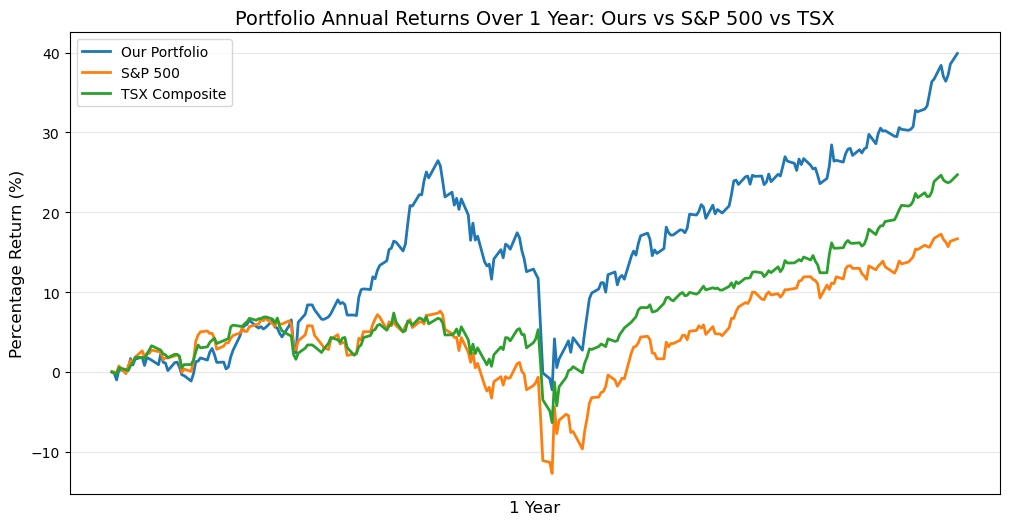

In [ ]:
# Buy date = first date in your data
dates = data.index
start = dates[0]
end = dates[-1]

# USD/CAD FX rate on the buy date
fx_hist = yf.Ticker("CAD=X").history(start=start, end=start + pd.Timedelta(days=5))["Close"].dropna()
if len(fx_hist) == 0:
    usd_to_cad = 1.35   # simple fallback
else:
    usd_to_cad = fx_hist.iloc[0]

# our portfolio value over time (CAD)
def portfolio_value_series(final_df, data, usd_to_cad):
    total_series = None
    
    for i in range(len(final_df)):
        ticker = final_df.loc[i, "ticker"]
        shares = final_df.loc[i, "Shares"]
        currency = final_df.loc[i, "Currency"]
        
        px = data[ticker]["Close"].reindex(dates).ffill()
        
        # convert USD stocks to CAD
        if currency == "USD":
            px = px * usd_to_cad
        
        value = px * shares
        
        if total_series is None:
            total_series = value
        else:
            total_series = total_series.add(value, fill_value=0.0)
    
    return total_series

our_series = portfolio_value_series(final_portfolio, data, usd_to_cad)

# make sure our_series index is timezone-naive
try:
    our_series.index = our_series.index.tz_localize(None)
except (TypeError, AttributeError):
    pass

# S&P 500 
sp = yf.Ticker("^GSPC").history(
    start=our_series.index[0],
    end=our_series.index[-1] + pd.Timedelta(days=1)
)["Close"].dropna()

try:
    sp.index = sp.index.tz_localize(None)
except (TypeError, AttributeError):
    pass

# TSX Composite 
tsx = yf.Ticker("^GSPTSE").history(
    start=our_series.index[0],
    end=our_series.index[-1] + pd.Timedelta(days=1)
)["Close"].dropna()

try:
    tsx.index = tsx.index.tz_localize(None)
except (TypeError, AttributeError):
    pass

# line everything up on our portfolio dates
common_dates = our_series.index

sp_aligned = sp.reindex(common_dates).ffill()
tsx_aligned = tsx.reindex(common_dates).ffill()

# convert all three to % return (start at 0%)
our_pct = (our_series / our_series.iloc[0] - 1.0) * 100
sp_pct = (sp_aligned / sp_aligned.iloc[0] - 1.0) * 100
tsx_pct = (tsx_aligned / tsx_aligned.iloc[0] - 1.0) * 100

# plot 
plt.figure(figsize=(12, 6))

plt.plot(common_dates, our_pct, label="Our Portfolio", linewidth=2)
plt.plot(common_dates, sp_pct, label="S&P 500", linewidth=2)
plt.plot(common_dates, tsx_pct, label="TSX Composite", linewidth=2)

plt.title("Portfolio Annual Returns Over 1 Year: Ours vs S&P 500 vs TSX", fontsize=14)
plt.ylabel("Percentage Return (%)", fontsize=12)
plt.xlabel("1 Year", fontsize=12)
plt.xticks([]) 
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


Our portfolio massively outperformed the S&P 500 and the TSX 100 over this one year window. It isn't surprising considering our strategy is deliberately concentrated in the strongest signals instead of holding bits of the entire market. We ran a strict filter on residual momentum, Sharpe, beta stability, and liquidity, which means we only ended up buying stocks that were already performing above what CAPM would predict, and were doing so in a high volume way. The S&P and TSX, on the other hand, are forced to hold everything, including slow moving large caps, sectors that were out of favor, and names with poor recent performance.

All three portfolios experience a sharp drawdown around April 2025 during the market crash, which is exactly what you would expect from broad systemic risk. However, our portfolio recovers much faster and ends up pulling away from both benchmarks, which suggests that the stocks we selected not only held up relatively well but also participated more strongly in the rebound.

Furthermore, we accepted a much higher risk profile than the benchmarks by holding only 10 stocks rather than hundreds. That concentration amplifies the impact of being right. When our signals worked, the gains from those winners moved the whole portfolio much more than they would inside a broad index. Our weighting process pushed more capital into stocks with strong Monte Carlo expected returns, solid CAPM expected returns, and good diversification properties, so the portfolio did not just ride the market. It specifically tilted toward tickers that the models suggested should outperform.

To be frank, the benchmarks are designed to be average. Our portfolio is not. It's not surprising we beat both indices by a wide margin.

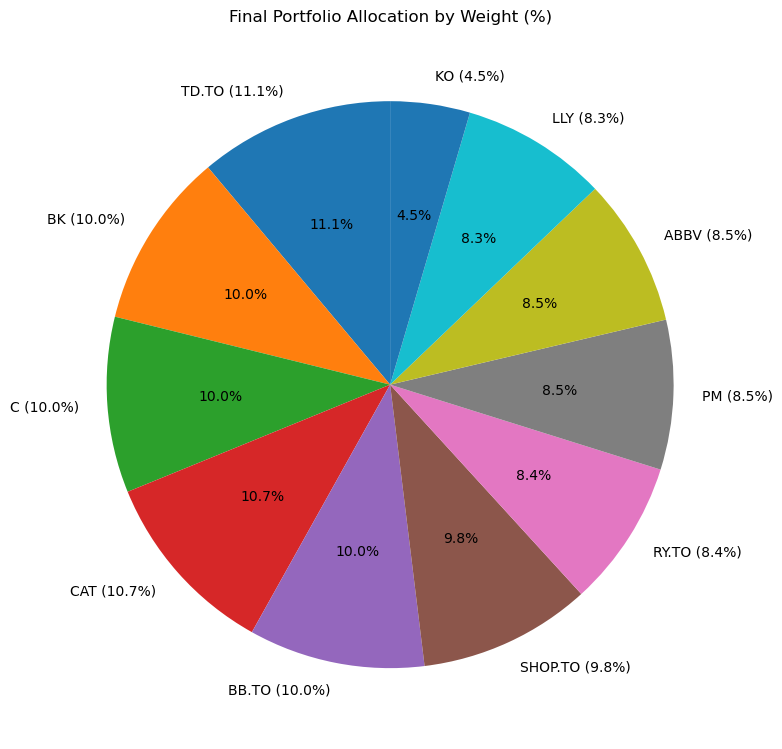

In [ ]:
def plot_portfolio_pie(selected_df):
    tickers = selected_df["ticker"]
    weights = selected_df["weight"] * 100   # convert to percentage

    labels = []
    for i in range(len(tickers)):
        t = tickers[i]
        w = weights[i]
        labels.append(f"{t} ({w:.1f}%)")

    plt.figure(figsize=(8, 8))
    plt.pie(weights, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title("Final Portfolio Allocation by Weight (%)")
    plt.tight_layout()
    plt.show()

plot_portfolio_pie(optimized_portfolio)

Data Visualization to help understand the weight of each stock.

In [ ]:
# Create the final portfolio dataframe
Portfolio_Final = final_portfolio.copy()

# Export the final portfolio to CSV (no index column)
Portfolio_Final.to_csv("Portfolio_Final.csv", index=False)